Simulation analysis           *** Written by Fj at AIME lab 2026

# pip install rdkit-pypi MDAnalysis py3Dmol ipywidgets

In [ ]:
# ------------------ Inputs 
protac_name = 'PROTAC-1'         # protac name
name_prefix = "Chloroform"       # environment 
run_id = "1"
print("Protac name:", protac_name,name_prefix)
ligand_resname = "protac"            # residue name to select from topology

Protac name: PROTAC-1 Chloroform


In [ ]:
# Combine replica trajectories into one trajectory file and skip frames to reduce file size (GROMACS)
!echo 2 | gmx trjconv -f rep1234.wrapF.xtc -s initial.gro -o skip8_5000fr.xtc -skip 8
!gmx check -f skip8_5000fr.xtc

                 :-) GROMACS - gmx trjconv, 2025.1-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.1/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.1
Working dir:  /Users/farjal/Library/CloudStorage/OneDrive-Chalmers/Documents/Generator/Moltiverse_analysis/3.Simulation_and_analysis/new_Set/2.Simulation_dardel_finalset/3895_simulation_p
Command line:
  gmx trjconv -f rep1234.wrapF.xtc -s initial.gro -o skip8_5000fr.xtc -skip 8

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write xtc: Compressed trajectory (portable xdr format): xtc
Select group for output
Group     0 (         System) has    90 elements
Group     1 (          Other) has    90 elements
Group     2 (            rot) has    90 elements
Select a group: Selected 2: 'rot'
Reading frame       0 time    0.000   
Precision of rep1234.wrapF.xtc is 0.001 (nm)
Using output precision of 0.001 (nm)

Back Off! I just backed up skip8_5000fr.xtc to 

In [ ]:
# remove water and ions from the trajectory (GROMACS)

import MDAnalysis as mda

# --- Inputs ---
topM = "initial.gro"            # topology that contains protac
xtcM = "rep1234.wrapF.xtc"      # original trajectory
out_xtc = "ligand.xtc" 
out_pdb = "ligand.pdb"
# --- Load system ---
u = mda.Universe(topM, xtcM)

# --- Select ligand by residue name ---
ligand = u.select_atoms("resname protac")
if ligand.n_atoms == 0:
    raise ValueError("No atoms with resname protac found in topology!")

print(f"Ligand has {ligand.n_atoms} atoms")

# --- Write ligand trajectory (all frames, XTC) ---
with mda.Writer(out_xtc, ligand.n_atoms) as W:
    for ts in u.trajectory:
        W.write(ligand)

print(f"Saved ligand trajectory to {out_xtc}")

# --- Write ligand-only PDB (topology reference) ---
ligand.write(out_pdb)
print(f"Saved ligand topology to {out_pdb}")

Ligand has 90 atoms
Saved ligand trajectory to ligand.xtc
Saved ligand topology to ligand.pdb


In [ ]:
# for H-bond calculation

import MDAnalysis as mda

# --- Inputs ---
topM_hb = "initial.gro"           # topology that contains protac
xtcM_hb = "skip8_5000fr.xtc"      # original trajectory
out_xtc = "ligand_hb.xtc" 
out_pdb = "ligand_hb.pdb"
# --- Load system ---
u = mda.Universe(topM_hb, xtcM_hb)

# --- Select ligand by residue name ---
ligand = u.select_atoms("resname protac")
if ligand.n_atoms == 0:
    raise ValueError("No atoms with resname protac found in topology!")

print(f"Ligand has {ligand.n_atoms} atoms")

# --- Write ligand trajectory (all frames, XTC) ---
with mda.Writer(out_xtc, ligand.n_atoms) as W:
    for ts in u.trajectory:
        W.write(ligand)

print(f"Saved ligand trajectory to {out_xtc}")

# --- Write ligand-only PDB (topology reference) ---
ligand.write(out_pdb)
print(f"Saved ligand topology to {out_pdb}")

/Users/farjal/miniforge3/envs/confgenerator_env/lib/python3.12/site-packages/MDAnalysis/coordinates/XDR.py:253: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


Ligand has 90 atoms
Saved ligand trajectory to ligand_hb.xtc
Saved ligand topology to ligand_hb.pdb


In [ ]:
# --- input files 
top_file = "ligand.pdb"   # PDB that matches the XTC (same atoms & order)
xtc_file = "ligand.xtc"   # your XTC trajectory

In [ ]:
# 3D visualization of the ligand trajectory using RDKit and py3Dmol

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Geometry import Point3D
import MDAnalysis as mda
import py3Dmol
import ipywidgets as widgets
from ipywidgets import interact

# --- 1) Load trajectory with MDAnalysis ---
u = mda.Universe(top_file, xtc_file)

n_atoms = u.atoms.n_atoms
n_frames = len(u.trajectory)
print(f"Trajectory: {n_atoms} atoms, {n_frames} frames")

# --- 2) Build an RDKit template from the topology (bonds/chemistry) ---
mol0 = Chem.MolFromPDBFile(top_file, removeHs=False, sanitize=True)
if mol0 is None:
    # Fallback if sanitize fails on unusual residues
    mol0 = Chem.MolFromPDBFile(top_file, removeHs=False, sanitize=False)
    Chem.SanitizeMol(mol0)

if mol0.GetNumAtoms() != n_atoms:
    raise ValueError(
        f"Atom count mismatch: topology PDB has {mol0.GetNumAtoms()} atoms, "
        f"but XTC/topology reports {n_atoms}."
    )

# --- 3) Add each XTC frame as a conformer ---
mol = Chem.Mol(mol0)
mol.RemoveAllConformers()

for i, ts in enumerate(u.trajectory):  # positions in Å
    conf = Chem.Conformer(n_atoms)
    coords = ts.positions  # Å
    for idx in range(n_atoms):
        x, y, z = coords[idx]
        conf.SetAtomPosition(idx, Point3D(float(x), float(y), float(z)))
    conf.SetId(i)
    mol.AddConformer(conf, assignId=True)

print(f"Built RDKit molecule with {mol.GetNumConformers()} conformers.")

# Optional: align frames to the first for smooth scrubbing
try:
    AllChem.AlignMolConformers(mol)
except Exception:
    pass

# --- 4) Minimal 3D viewer ---
def view_frame(idx1=1, style='stick'):
    confId = idx1 - 1
    pdb_block = Chem.MolToPDBBlock(mol, confId=confId)
    v = py3Dmol.view(width=640, height=480)
    v.addModel(pdb_block, 'pdb')
    v.setStyle({style: {}})  # 'stick', 'line', 'sphere'
    v.zoomTo()
    return v

interact(
    view_frame,
    idx1=widgets.IntSlider(min=1, max=mol.GetNumConformers(), step=1, value=1, description='Frame'),
    style=widgets.Dropdown(options=['stick', 'line', 'sphere'], value='stick', description='Style'),
)

/Users/farjal/miniforge3/envs/confgenerator_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/Users/farjal/miniforge3/envs/confgenerator_env/lib/python3.12/site-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


Trajectory: 90 atoms, 40001 frames
Built RDKit molecule with 40001 conformers.


interactive(children=(IntSlider(value=1, description='Frame', max=40001, min=1), Dropdown(description='Style',…

<function __main__.view_frame(idx1=1, style='stick')>

In [ ]:
##### SASA and  Rg calculation

import numpy as np
import pandas as pd
import mdtraj as md

output_csv = f"sasa_rg_{protac_name}.csv"

traj = md.load(xtc_file , top=top_file)

ligand_atoms = traj.topology.select(f"resname {ligand_resname}")
lig_traj = traj.atom_slice(ligand_atoms)

sasa = md.shrake_rupley(lig_traj).sum(axis=1) * 100.0
rg = md.compute_rg(lig_traj) * 10.0

df = pd.DataFrame({
    "frame": np.arange(lig_traj.n_frames),
    "SASA": sasa,
    "Rg": rg
})

df.to_csv(output_csv, index=False)
print(f"Saved: {output_csv}")

df.head()

Saved: sasa_rg_PROTAC-1.csv


,frame,SASA,Rg
0,0,1002.825256,5.771024
1,1,1035.177856,5.960604
2,2,1017.761414,5.962995
3,3,947.004578,5.518022
4,4,985.236267,5.604536


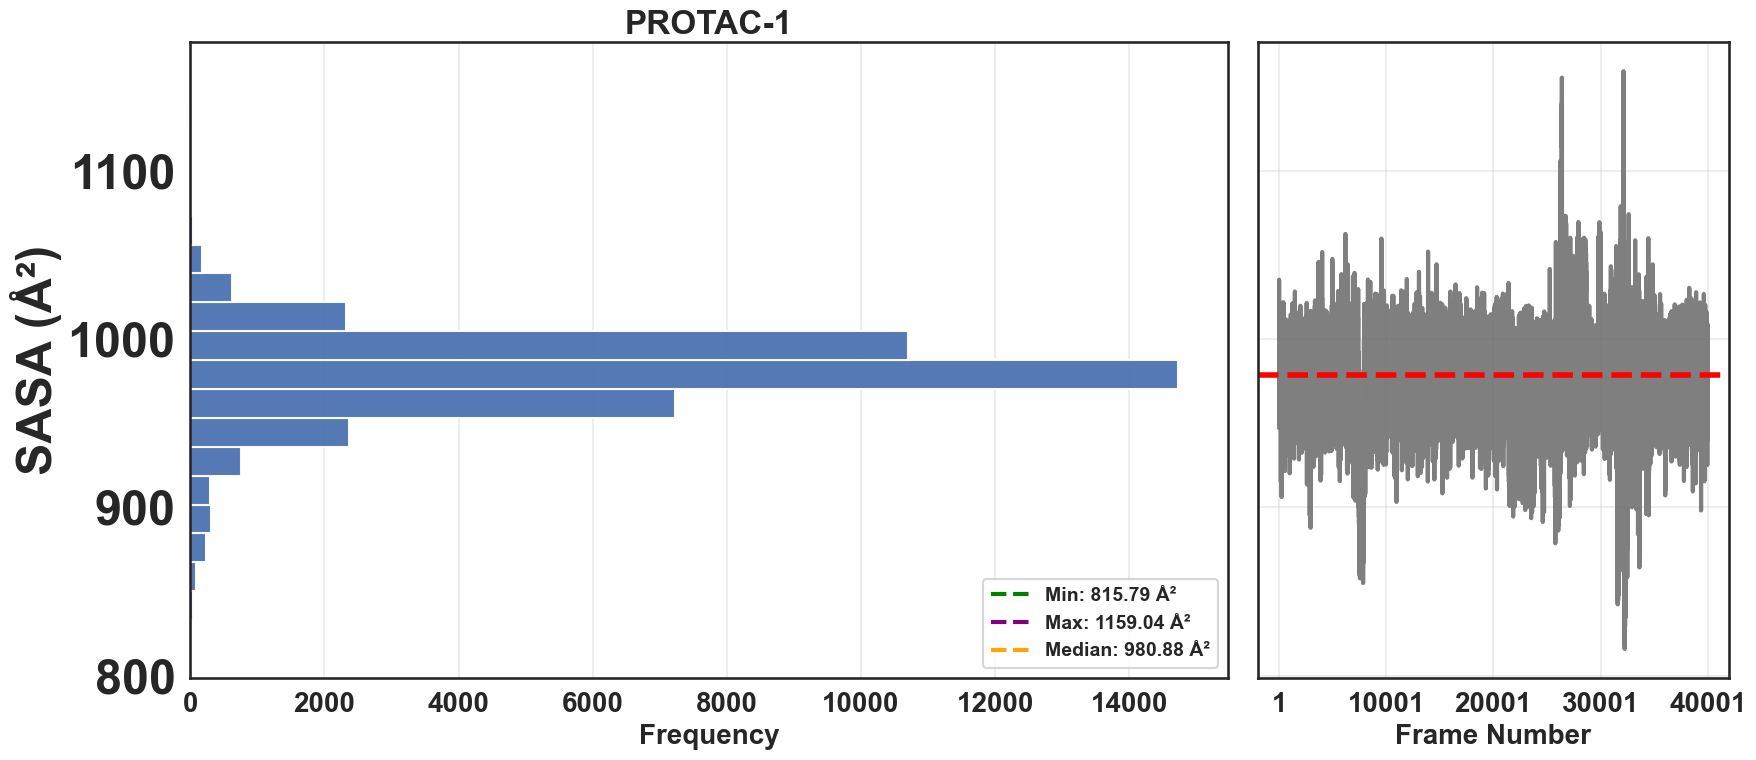

In [ ]:
### SASA histogram and line plot

import numpy as np
import matplotlib.pyplot as plt

#limits
XLIM_SASA = None
YLIM_SASA = None   

hist_color = "#4C72B0"

min_sasa = df["SASA"].min()
max_sasa = df["SASA"].max()
median_sasa = df["SASA"].median()
mean_sasa = df["SASA"].mean()

fig, ax = plt.subplots(
    1, 2,
    figsize=(18, 8),
    sharey=True,
    gridspec_kw={"width_ratios": [2.2, 1]}
)

ax[0].hist(
    df["SASA"],
    bins=20,
    orientation="horizontal",
    color=hist_color,
    edgecolor="white",
    alpha=0.95
)

ax[0].plot([], [], color="green", linestyle="--", linewidth=3,
           label=f"Min: {min_sasa:.2f} Å²")
ax[0].plot([], [], color="purple", linestyle="--", linewidth=3,
           label=f"Max: {max_sasa:.2f} Å²")
ax[0].plot([], [], color="orange", linestyle="--", linewidth=3,
           label=f"Median: {median_sasa:.2f} Å²")

ax[0].set_title(f"{protac_name}", fontweight="bold")
ax[0].set_xlabel("Frequency", fontweight="bold", fontsize=20)
ax[0].set_ylabel("SASA (Å²)", fontweight="bold", fontsize=35)
ax[0].grid(axis="x", alpha=0.35)
ax[0].legend(loc="lower right")

if YLIM_SASA is not None:
    ax[0].set_ylim(YLIM_SASA)

if XLIM_SASA is not None:
    ax[0].set_xlim(XLIM_SASA)

ax[1].plot(
    df.index + 1,
    df["SASA"],
    linestyle="-",
    color="dimgray",
    linewidth=3,
    alpha=0.85
)

ax[1].axhline(
    mean_sasa,
    color="red",
    linestyle="--",
    linewidth=4
)

ax[1].set_xlabel("Frame Number", fontweight="bold", fontsize=20)
ax[1].grid(True, alpha=0.35)

n_ticks = 5
tick_positions = np.linspace(0, len(df) - 1, n_ticks, dtype=int) + 1

ax[1].set_xticks(tick_positions)
ax[1].set_xticklabels(tick_positions)

for a in ax:
    a.tick_params(axis="x", labelsize=20, width=2.5, length=7)
    a.tick_params(axis="y", labelsize=35, width=2.5, length=7)

    for label in a.get_xticklabels():
        label.set_fontweight("bold")

    for label in a.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
plt.savefig(
    f"sasa_histogram_line_side_{protac_name}_{run_id}_{name_prefix}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

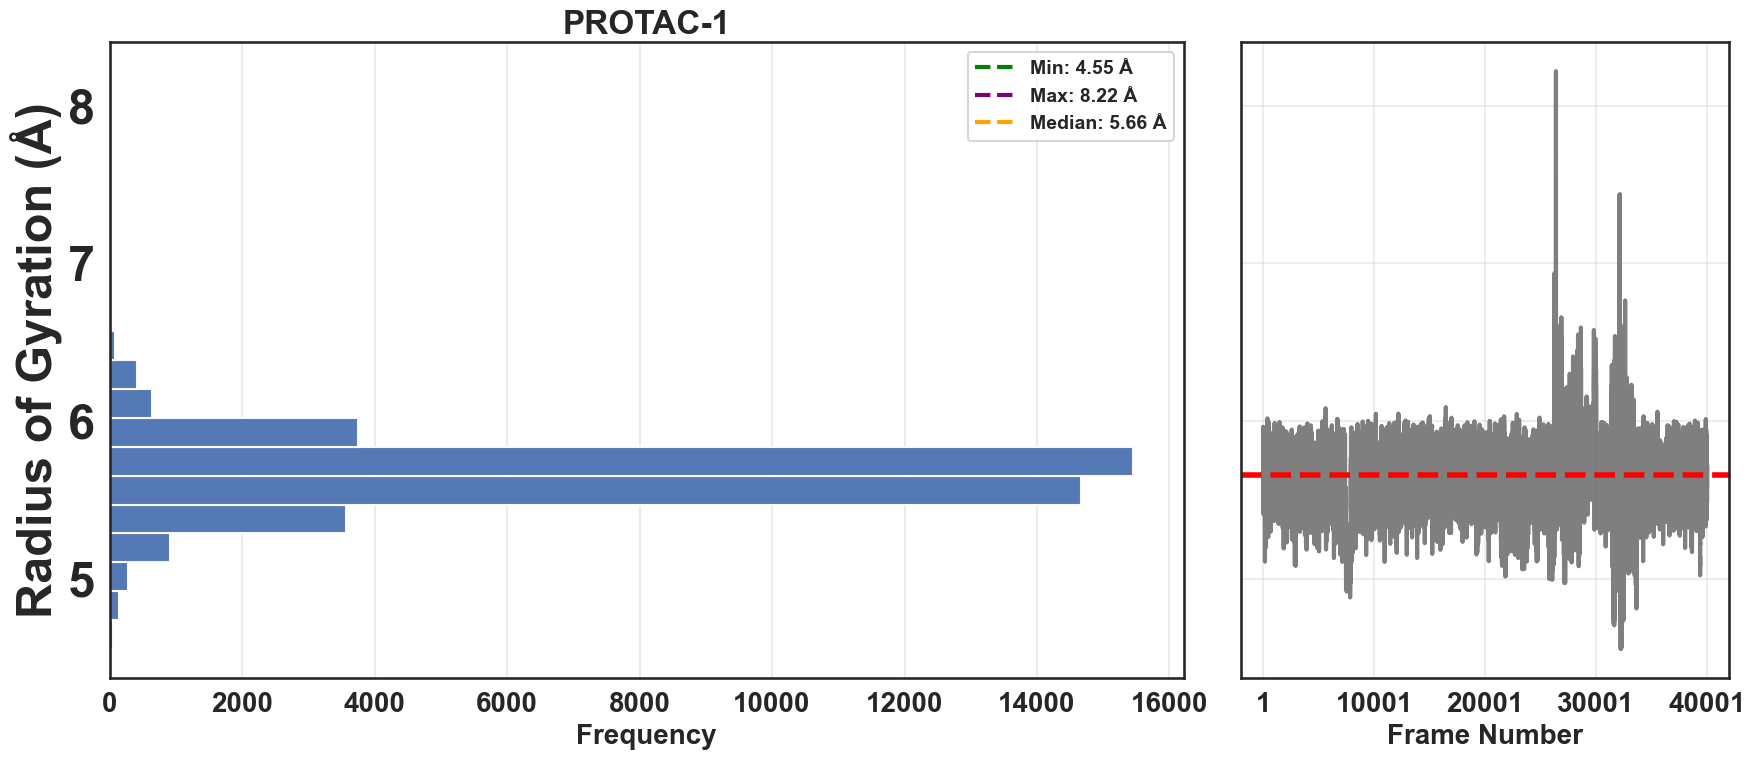

In [ ]:
#### Rg histogram and line plot
import numpy as np
import matplotlib.pyplot as plt

XLIM_RG = None
YLIM_RG = None   # Example: (4, 14)

hist_color = "#4C72B0"

min_rg = df["Rg"].min()
max_rg = df["Rg"].max()
median_rg = df["Rg"].median()
mean_rg = df["Rg"].mean()

fig, ax = plt.subplots(
    1, 2,
    figsize=(18, 8),
    sharey=True,
    gridspec_kw={"width_ratios": [2.2, 1]}
)

ax[0].hist(
    df["Rg"],
    bins=20,
    orientation="horizontal",
    color=hist_color,
    edgecolor="white",
    alpha=0.95
)

ax[0].plot([], [], color="green", linestyle="--", linewidth=3,
           label=f"Min: {min_rg:.2f} Å")
ax[0].plot([], [], color="purple", linestyle="--", linewidth=3,
           label=f"Max: {max_rg:.2f} Å")
ax[0].plot([], [], color="orange", linestyle="--", linewidth=3,
           label=f"Median: {median_rg:.2f} Å")

ax[0].set_title(f"{protac_name}", fontweight="bold")
ax[0].set_xlabel("Frequency", fontweight="bold", fontsize=20)
ax[0].set_ylabel("Radius of Gyration (Å)", fontweight="bold", fontsize=35)
ax[0].grid(axis="x", alpha=0.35)
ax[0].legend(loc="upper right")

if YLIM_RG is not None:
    ax[0].set_ylim(YLIM_RG)

if XLIM_RG is not None:
    ax[0].set_xlim(XLIM_RG)

ax[1].plot(
    df.index + 1,
    df["Rg"],
    linestyle="-",
    color="dimgray",
    linewidth=3,
    alpha=0.85
)

ax[1].axhline(
    mean_rg,
    color="red",
    linestyle="--",
    linewidth=4
)

ax[1].set_xlabel("Frame Number", fontweight="bold", fontsize=20)
ax[1].grid(True, alpha=0.35)

n_ticks = 5
tick_positions = np.linspace(0, len(df) - 1, n_ticks, dtype=int) + 1

ax[1].set_xticks(tick_positions)
ax[1].set_xticklabels(tick_positions)

for a in ax:
    a.tick_params(axis="x", labelsize=20, width=2.5, length=7)
    a.tick_params(axis="y", labelsize=35, width=2.5, length=7)

    for label in a.get_xticklabels():
        label.set_fontweight("bold")

    for label in a.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
plt.savefig(
    f"rg_histogram_line_side_{protac_name}_{run_id}_{name_prefix}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [ ]:
### Energy calculation and table for all
import os
import mdtraj as md
import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem

# silence RDKit warning messages
RDLogger.DisableLog('rdApp.warning')

output_csv = f"sasa_rg_energy_{protac_name}_{run_id}_{name_prefix}.csv"

# Load trajectory
traj = md.load(xtc_file, top=top_file)

energies = []
forcefield_used = []

for i in range(traj.n_frames):
    temp_pdb = f"temp_energy_{i}.pdb"

    try:
        # Save one frame as PDB
        traj[i].save_pdb(temp_pdb)

        # Read exactly as-is, no AddHs
        mol = Chem.MolFromPDBFile(temp_pdb, removeHs=False, sanitize=True)

        if mol is None:
            print(f"Could not read frame {i}")
            energies.append(None)
            forcefield_used.append(None)
            continue

        if mol.GetNumConformers() == 0:
            print(f"No conformer for frame {i}")
            energies.append(None)
            forcefield_used.append(None)
            continue

        # MMFF if possible, otherwise UFF
        if AllChem.MMFFHasAllMoleculeParams(mol):
            props = AllChem.MMFFGetMoleculeProperties(mol)
            ff = AllChem.MMFFGetMoleculeForceField(mol, props)
            energy = ff.CalcEnergy() if ff is not None else None
            ff_name = "MMFF"
        else:
            ff = AllChem.UFFGetMoleculeForceField(mol)
            energy = ff.CalcEnergy() if ff is not None else None
            ff_name = "UFF" if ff is not None else None

        energies.append(energy)
        forcefield_used.append(ff_name)

    except Exception as e:
        print(f"Error at frame {i}: {e}")
        energies.append(None)
        forcefield_used.append(None)

    finally:
        if os.path.exists(temp_pdb):
            os.remove(temp_pdb)

# Read your existing sasa/rg file
input_csv = f"sasa_rg_{protac_name}.csv"
df = pd.read_csv(input_csv)

# Match lengths safely
if len(df) != len(energies):
    min_len = min(len(df), len(energies))
    print(f"Warning: CSV rows ({len(df)}) and trajectory frames ({len(energies)}) differ. Truncating to {min_len}.")
    df = df.iloc[:min_len].copy()
    energies = energies[:min_len]
    forcefield_used = forcefield_used[:min_len]

# Add columns
df["Energy"] = energies
df["ForceField"] = forcefield_used

# Save
df.to_csv(output_csv, index=False)
print("Energy calculation updated and saved to", output_csv)

df.head()

Energy calculation updated and saved to sasa_rg_energy_PROTAC-1_1_Chloroform.csv


,frame,SASA,Rg,Energy,ForceField
0,0,1002.82526,5.771024,609.208031,MMFF
1,1,1035.17790,5.960604,609.883145,MMFF
2,2,1017.76140,5.962995,638.809973,MMFF
3,3,947.00460,5.518022,628.715659,MMFF
4,4,985.23627,5.604536,622.926201,MMFF


Figure saved as energy_histogram_flipped_PROTAC-1_1_Chloroform.png


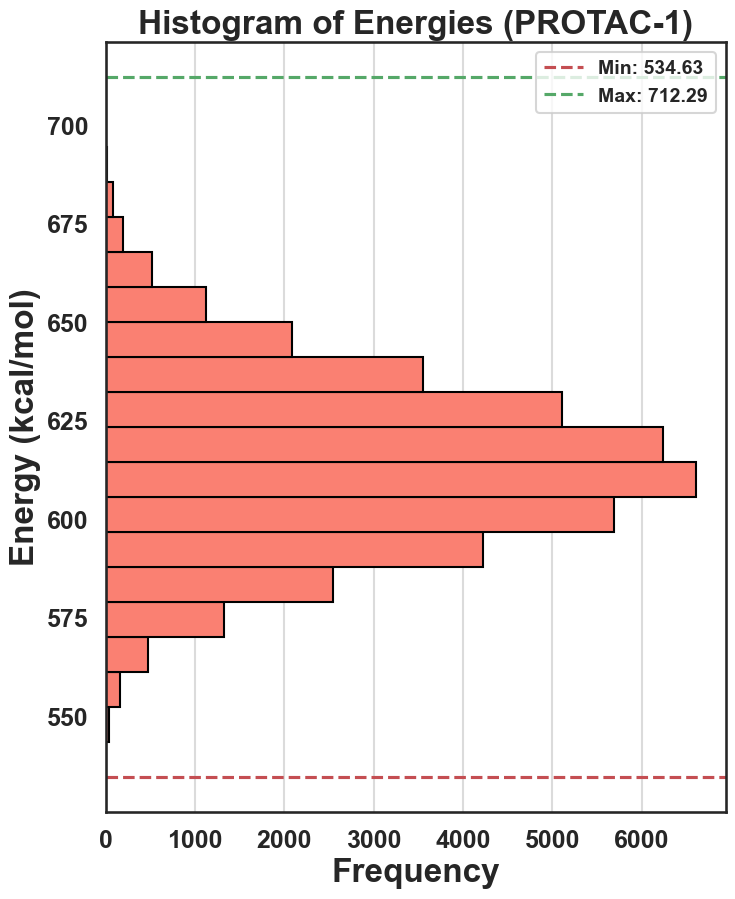

In [40]:
# Energy Histograms

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

input_csv = f"sasa_rg_energy_{protac_name}_{run_id}_{name_prefix}.csv"

df = pd.read_csv(input_csv)
df = df.dropna(subset=["Energy"])
energies = df["Energy"]

counts, bins = np.histogram(energies, bins=20)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# Flipped histogram
plt.figure(figsize=(8, 10))
plt.barh(
    bin_centers,
    counts,
    height=(bins[1] - bins[0]),
    color="salmon",
    edgecolor="black"
)

plt.title(f"Histogram of Energies ({protac_name})")
plt.ylabel("Energy (kcal/mol)")
plt.xlabel("Frequency")
plt.grid(axis="x", alpha=0.7)


# Lines for min and max energy
plt.axhline(energies.min(), color="r", linestyle="--", label=f"Min: {energies.min():.2f}")
plt.axhline(energies.max(), color="g", linestyle="--", label=f"Max: {energies.max():.2f}")
plt.legend()


output_png = f"energy_histogram_flipped_{protac_name}_{run_id}_{name_prefix}.png"
plt.savefig(output_png, dpi=300, bbox_inches="tight")
print(f"Figure saved as {output_png}")

plt.show()

✅ PSA plot saved as psa_histogram_line_energy_filtered_PROTAC-1_1_Chloroform.png


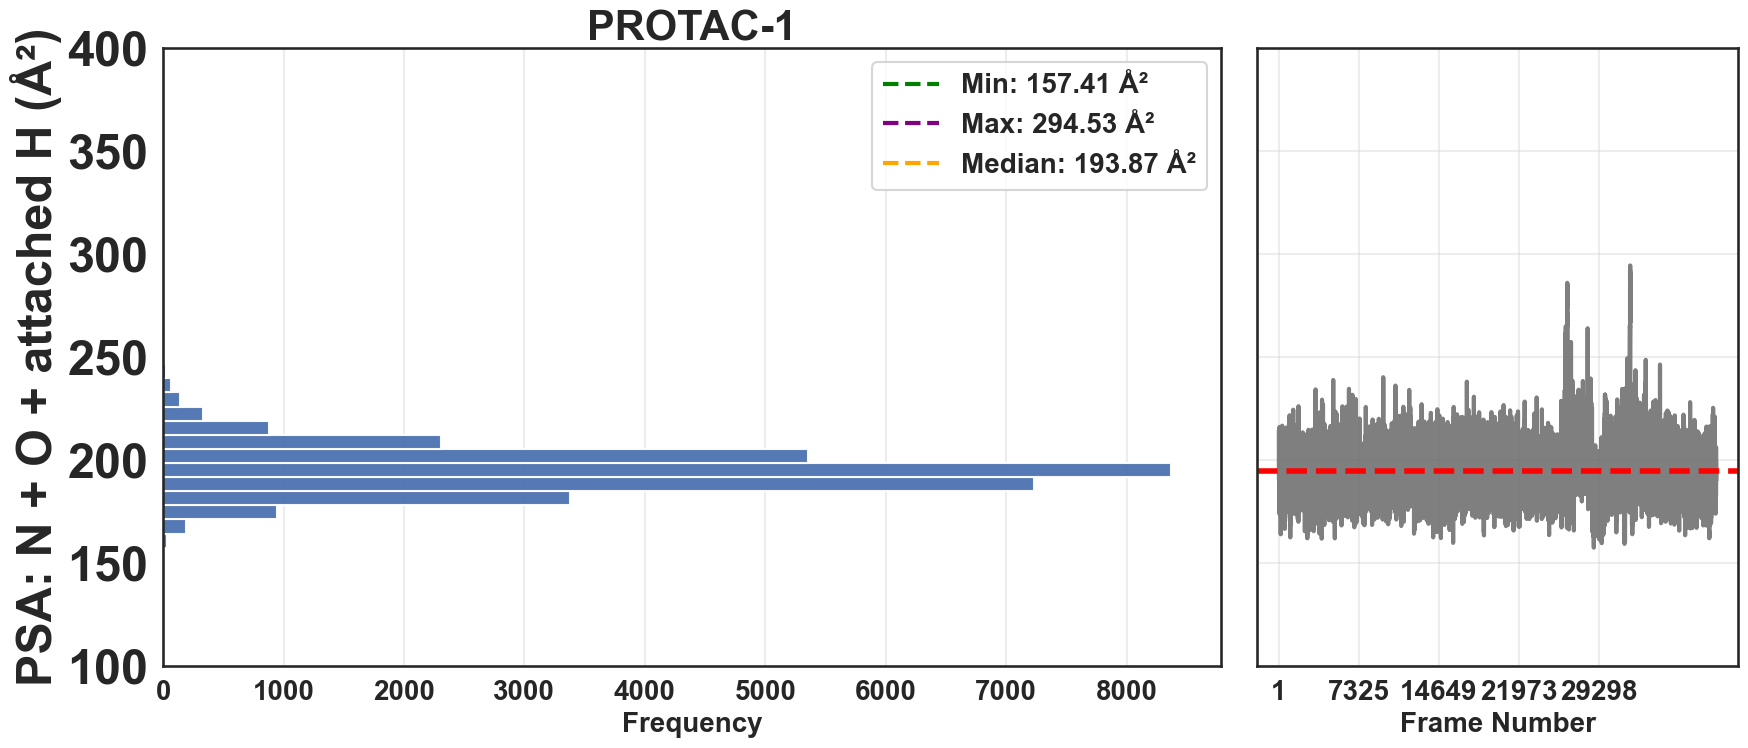

In [ ]:
## PSA histogram + line plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ PSA histogram + line plot ------------------

XLIM_PSA = None
YLIM_PSA = (100, 400)   # change or set to None
ELIM_ENERGY = (600, 800)

hist_color = "#4C72B0"

input_csv = f"sasa_rg_energy_psa_{protac_name}_{run_id}_{name_prefix}.csv"

df = pd.read_csv(input_csv)

df_clean = df.dropna(subset=["Energy", "Rg", "PSA"]).copy()

if ELIM_ENERGY is not None:
    df_clean = df_clean[
        (df_clean["Energy"] >= ELIM_ENERGY[0]) &
        (df_clean["Energy"] <= ELIM_ENERGY[1])
    ].copy()

if df_clean.empty:
    raise ValueError("No data left after filtering. Check ELIM_ENERGY or input file.")

psa = df_clean["PSA"]

min_psa = psa.min()
max_psa = psa.max()
median_psa = psa.median()
mean_psa = psa.mean()

plt.rcParams.update({
    "font.size": 24,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 30,
    "axes.labelsize": 32,
    "xtick.labelsize": 20,
    "ytick.labelsize": 35,
    "legend.fontsize": 20,
})

fig, ax = plt.subplots(
    1, 2,
    figsize=(18, 8),
    sharey=True,
    gridspec_kw={"width_ratios": [2.2, 1]}
)

ax[0].hist(
    psa,
    bins=20,
    orientation="horizontal",
    color=hist_color,
    edgecolor="white",
    alpha=0.95
)

ax[0].plot([], [], color="green", linestyle="--", linewidth=3,
           label=f"Min: {min_psa:.2f} Å²")
ax[0].plot([], [], color="purple", linestyle="--", linewidth=3,
           label=f"Max: {max_psa:.2f} Å²")
ax[0].plot([], [], color="orange", linestyle="--", linewidth=3,
           label=f"Median: {median_psa:.2f} Å²")

ax[0].set_title(f"{protac_name}", fontweight="bold")
ax[0].set_xlabel("Frequency", fontweight="bold", fontsize=20)
ax[0].set_ylabel("PSA: N + O + attached H (Å²)", fontweight="bold", fontsize=35)
ax[0].grid(axis="x", alpha=0.35)
ax[0].legend(loc="upper right")

if YLIM_PSA is not None:
    ax[0].set_ylim(YLIM_PSA)

if XLIM_PSA is not None:
    ax[0].set_xlim(XLIM_PSA)

ax[1].plot(
    df_clean.index + 1,
    psa,
    linestyle="-",
    color="dimgray",
    linewidth=3,
    alpha=0.85
)

ax[1].axhline(
    mean_psa,
    color="red",
    linestyle="--",
    linewidth=4
)

ax[1].set_xlabel("Frame Number", fontweight="bold", fontsize=20)
ax[1].grid(True, alpha=0.35)

n_ticks = 5
tick_positions = np.linspace(0, len(df_clean) - 1, n_ticks, dtype=int) + 1

ax[1].set_xticks(tick_positions)
ax[1].set_xticklabels(tick_positions)

for a in ax:
    a.tick_params(axis="x", labelsize=20, width=2.5, length=7)
    a.tick_params(axis="y", labelsize=35, width=2.5, length=7)

    for label in a.get_xticklabels():
        label.set_fontweight("bold")

    for label in a.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()

filename = f"psa_histogram_line_energy_filtered_{protac_name}_{run_id}_{name_prefix}.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")

print(f"✅ PSA plot saved as {filename}")

plt.show()
plt.close()

In [43]:
# ------------------ Add PSA column to existing sasa/rg/energy CSV ------------------

import numpy as np
import pandas as pd
import mdtraj as md

# Input = your existing combined sasa/rg/energy file
input_csv = f"sasa_rg_energy_{protac_name}_{run_id}_{name_prefix}.csv"

# Output = same data + PSA column
output_csv = f"sasa_rg_energy_psa_{protac_name}_{run_id}_{name_prefix}.csv"

# Load trajectory
traj = md.load(xtc_file, top=top_file)

# Select O, N, and H attached to O/N
polar_atoms = set()

for atom in traj.topology.atoms:
    elem = atom.element.symbol if atom.element is not None else ""

    if elem in {"N", "O"}:
        polar_atoms.add(atom.index)

        for atom1, atom2 in traj.topology.bonds:
            if atom1 == atom and atom2.element is not None and atom2.element.symbol == "H":
                polar_atoms.add(atom2.index)
            elif atom2 == atom and atom1.element is not None and atom1.element.symbol == "H":
                polar_atoms.add(atom1.index)

polar_atoms = sorted(polar_atoms)

if not polar_atoms:
    raise ValueError("No N/O atoms or attached H atoms found.")

# Calculate SASA for all atoms
sasa = md.shrake_rupley(traj, mode="atom")  # nm²

# PSA = SASA of polar atoms, converted from nm² to Å²
psa = sasa[:, polar_atoms].sum(axis=1) * 100.0

# Read existing sasa/rg/energy CSV
df = pd.read_csv(input_csv)

# Match lengths safely
if len(df) != len(psa):
    min_len = min(len(df), len(psa))
    print(f"Warning: CSV rows ({len(df)}) and PSA values ({len(psa)}) differ. Truncating to {min_len}.")
    df = df.iloc[:min_len].copy()
    psa = psa[:min_len]

# Add PSA as next column
df["PSA"] = psa

# Save combined output
df.to_csv(output_csv, index=False)

print("SASA/Rg/Energy/PSA file saved to:", output_csv)
print(f"Min PSA: {psa.min():.2f} Å²")
print(f"Max PSA: {psa.max():.2f} Å²")

df.head()

SASA/Rg/Energy/PSA file saved to: sasa_rg_energy_psa_PROTAC-1_1_Chloroform.csv
Min PSA: 157.41 Å²
Max PSA: 294.53 Å²


,frame,SASA,Rg,Energy,ForceField,PSA
0,0,1002.82526,5.771024,609.208031,MMFF,194.095322
1,1,1035.17790,5.960604,609.883145,MMFF,214.580536
2,2,1017.76140,5.962995,638.809973,MMFF,213.728073
3,3,947.00460,5.518022,628.715659,MMFF,190.404938
4,4,985.23627,5.604536,622.926201,MMFF,190.738846


Analyzes intramolecular hydrogen bonds (H-bonds) in a molecule

Min Energy: 534.630  Max Energy: 712.290
Figure saved as sasa_rg_energy_joint_clean_PROTAC-1_1_Chloroform.png


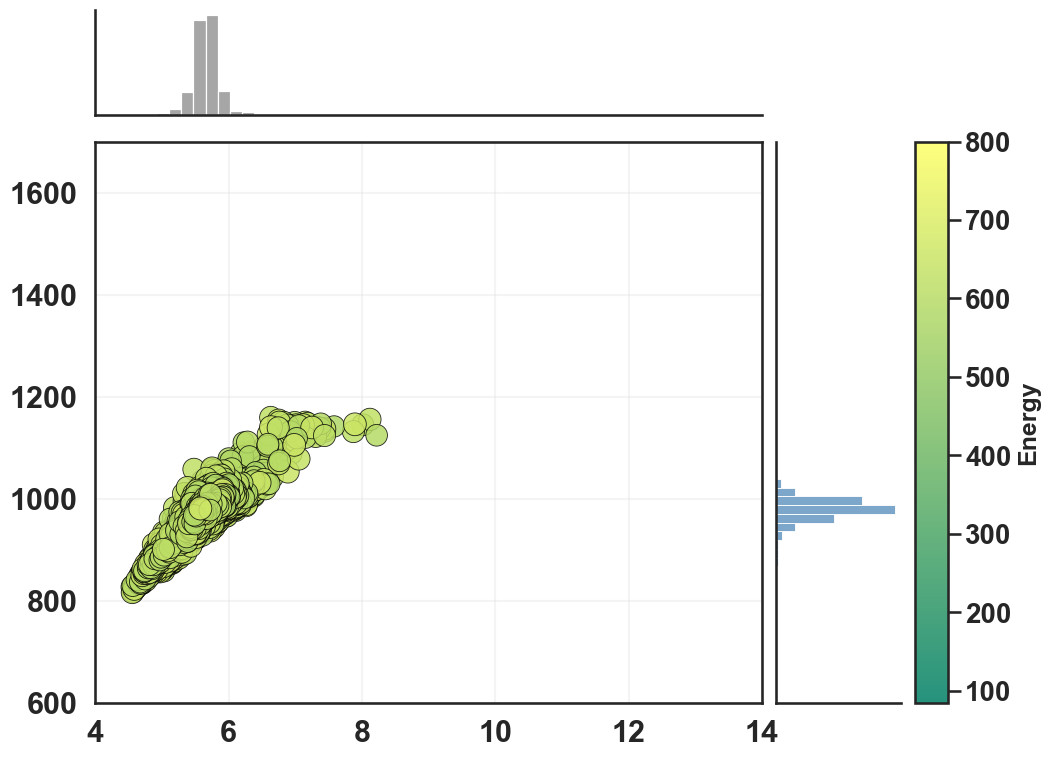

In [ ]:
## Histogram and scatter plot of SASA, Rg, and Energy
import MDAnalysis as mda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

cmap="summer" # colormap for energy
# limits
XLIM_RG = (4, 14)            # Rg
YLIM_SASA = (600, 1700)      # SASA
ELIM_ENERGY = (85, 800)     # Energy 

input_csv = f"sasa_rg_energy_{protac_name}_{run_id}_{name_prefix}.csv"
output_png = f"sasa_rg_energy_joint_clean_{protac_name}_{run_id}_{name_prefix}.png"

df = pd.read_csv(input_csv)

df_clean = df.dropna(subset=["Energy", "Rg", "SASA"]).copy()

if ELIM_ENERGY is not None:
    df_clean = df_clean[
        (df_clean["Energy"] >= ELIM_ENERGY[0]) &
        (df_clean["Energy"] <= ELIM_ENERGY[1])
    ].copy()

energy = df_clean["Energy"]
print(f"Min Energy: {energy.min():.3f}  Max Energy: {energy.max():.3f}")

# Normalize energy for color mapping
if ELIM_ENERGY is not None:
    vmin, vmax = ELIM_ENERGY
else:
    vmin, vmax = energy.min(), energy.max()

if vmax == vmin:
    norm = np.zeros(len(energy))
else:
    norm = np.clip((energy - vmin) / (vmax - vmin), 0, 1)

size = 300 * norm + 30

sns.set_theme(style="white", context="talk")

fig = plt.figure(figsize=(11, 9))
gs = GridSpec(
    2, 3,
    width_ratios=[8, 1.5, 0.4],
    height_ratios=[1.5, 8],
    wspace=0.05,
    hspace=0.08
)

ax_histx = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0], sharex=ax_histx)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
cax = fig.add_subplot(gs[1, 2])

# Main scatter
sc = ax.scatter(
    df_clean["Rg"],
    df_clean["SASA"],
    c=df_clean["Energy"],
    s=size,
    cmap=cmap,
    edgecolors="black",
    linewidths=0.6,
    alpha=0.85,
    vmin=vmin,
    vmax=vmax
)

ax.set_xlabel("Radius of Gyration (Å)", labelpad=10)
ax.set_ylabel("SASA (Å²)")
ax.set_title(f"---------------------------------------------------------------------------------------------------------{protac_name}", pad=10)
ax.grid(True, alpha=0.2)

if XLIM_RG is not None:
    ax.set_xlim(XLIM_RG)
if YLIM_SASA is not None:
    ax.set_ylim(YLIM_SASA)

# Top histogram (Rg)
sns.histplot(
    x=df_clean["Rg"],
    bins=20,
    ax=ax_histx,
    color="gray",
    alpha=0.7,
    edgecolor="white"
)

ax_histx.set_xlabel("")
ax_histx.set_ylabel("")
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.tick_params(axis="y", labelleft=False)

for spine in ["top", "right"]:
    ax_histx.spines[spine].set_visible(False)

# Right histogram (SASA)
sns.histplot(
    y=df_clean["SASA"],
    bins=20,
    ax=ax_histy,
    color="steelblue",
    alpha=0.7,
    edgecolor="white"
)

ax_histy.set_xlabel("")
ax_histy.set_ylabel("")
ax_histy.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

for spine in ["top", "right"]:
    ax_histy.spines[spine].set_visible(False)

ax_histx.set_xlim(ax.get_xlim())
ax_histy.set_ylim(ax.get_ylim())

cbar = plt.colorbar(sc, cax=cax)
cbar.set_label("Energy")
cbar.ax.tick_params(labelsize=20)


ax.tick_params(axis='both', labelsize=22)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

plt.savefig(output_png, dpi=300, bbox_inches="tight")
print(f"Figure saved as {output_png}")

plt.show()

Min Energy: 534.630  Max Energy: 712.290
Min PSA: 157.409  Max PSA: 294.534
Figure saved as rg_psa_energy_joint_clean_PROTAC-1_1_Chloroform.png


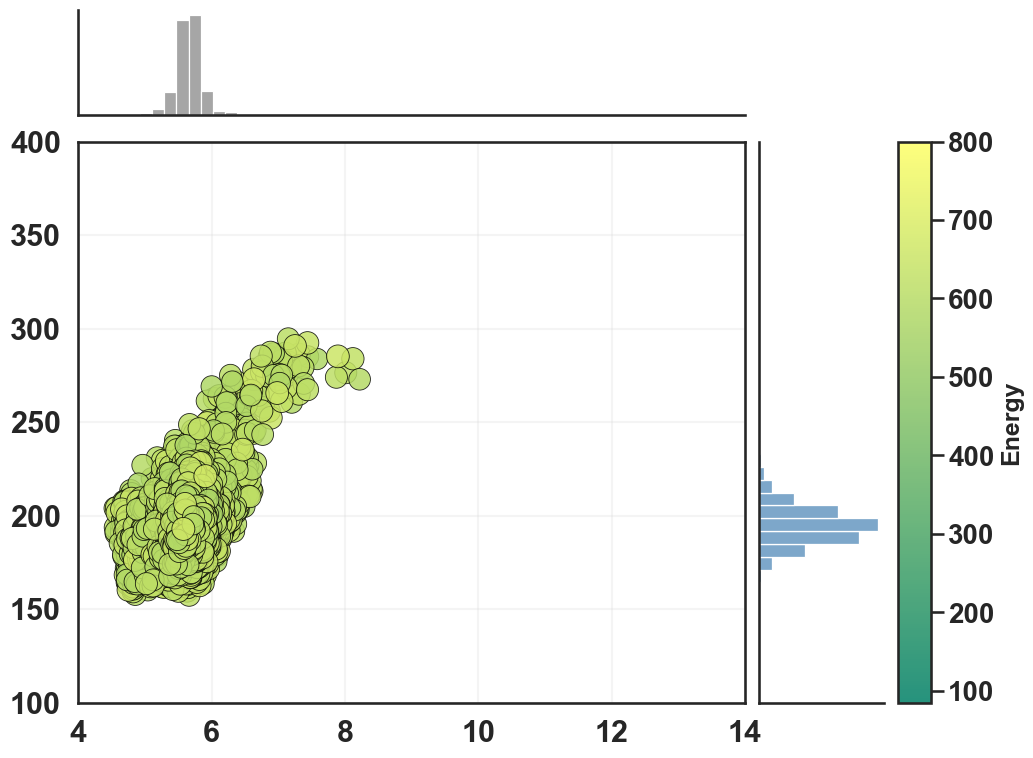

In [ ]:
# histogram and scatter plot of Rg, PSA, and Energy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

#limits
XLIM_RG = (4, 14)          # Rg
YLIM_PSA = (100, 400)      # PSA
ELIM_ENERGY = (85, 800)    # Energy 

input_csv = f"sasa_rg_energy_psa_{protac_name}_{run_id}_{name_prefix}.csv"
output_png = f"rg_psa_energy_joint_clean_{protac_name}_{run_id}_{name_prefix}.png"

df = pd.read_csv(input_csv)

df_clean = df.dropna(subset=["Energy", "Rg", "PSA"]).copy()

if ELIM_ENERGY is not None:
    df_clean = df_clean[
        (df_clean["Energy"] >= ELIM_ENERGY[0]) &
        (df_clean["Energy"] <= ELIM_ENERGY[1])
    ].copy()

energy = df_clean["Energy"]
print(f"Min Energy: {energy.min():.3f}  Max Energy: {energy.max():.3f}")
print(f"Min PSA: {df_clean['PSA'].min():.3f}  Max PSA: {df_clean['PSA'].max():.3f}")

# Normalize energy for color mapping
if ELIM_ENERGY is not None:
    vmin, vmax = ELIM_ENERGY
else:
    vmin, vmax = energy.min(), energy.max()

if vmax == vmin:
    norm = np.zeros(len(energy))
else:
    norm = np.clip((energy - vmin) / (vmax - vmin), 0, 1)

size = 300 * norm + 30

sns.set_theme(style="white", context="talk")

fig = plt.figure(figsize=(11, 9))
gs = GridSpec(
    2, 3,
    width_ratios=[8, 1.5, 0.4],
    height_ratios=[1.5, 8],
    wspace=0.05,
    hspace=0.08
)

ax_histx = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0], sharex=ax_histx)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
cax = fig.add_subplot(gs[1, 2])

# Main scatter: Rg vs PSA
sc = ax.scatter(
    df_clean["Rg"],
    df_clean["PSA"],
    c=df_clean["Energy"],
    s=size,
    cmap=cmap,
    edgecolors="black",
    linewidths=0.6,
    alpha=0.85,
    vmin=vmin,
    vmax=vmax
)

ax.grid(True, alpha=0.2)

if XLIM_RG is not None:
    ax.set_xlim(XLIM_RG)
if YLIM_PSA is not None:
    ax.set_ylim(YLIM_PSA)

# Top histogram: Rg
sns.histplot(
    x=df_clean["Rg"],
    bins=20,
    ax=ax_histx,
    color="gray",
    alpha=0.7,
    edgecolor="white"
)

ax_histx.set_xlabel("")
ax_histx.set_ylabel("")
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.tick_params(axis="y", labelleft=False)

for spine in ["top", "right"]:
    ax_histx.spines[spine].set_visible(False)

# Right histogram: PSA
sns.histplot(
    y=df_clean["PSA"],
    bins=20,
    ax=ax_histy,
    color="steelblue",
    alpha=0.7,
    edgecolor="white"
)

ax_histy.set_xlabel("")
ax_histy.set_ylabel("")
ax_histy.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

for spine in ["top", "right"]:
    ax_histy.spines[spine].set_visible(False)

ax_histx.set_xlim(ax.get_xlim())
ax_histy.set_ylim(ax.get_ylim())

# Colorbar
cbar = plt.colorbar(sc, cax=cax)
cbar.set_label("Energy")
cbar.ax.tick_params(labelsize=20)

# Tick style
ax.tick_params(axis="both", labelsize=22)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

plt.savefig(output_png, dpi=300, bbox_inches="tight")
print(f"Figure saved as {output_png}")

plt.show()

✅ Saved: energy_histogram_flipped_PROTAC-1_1_Chloroform.png


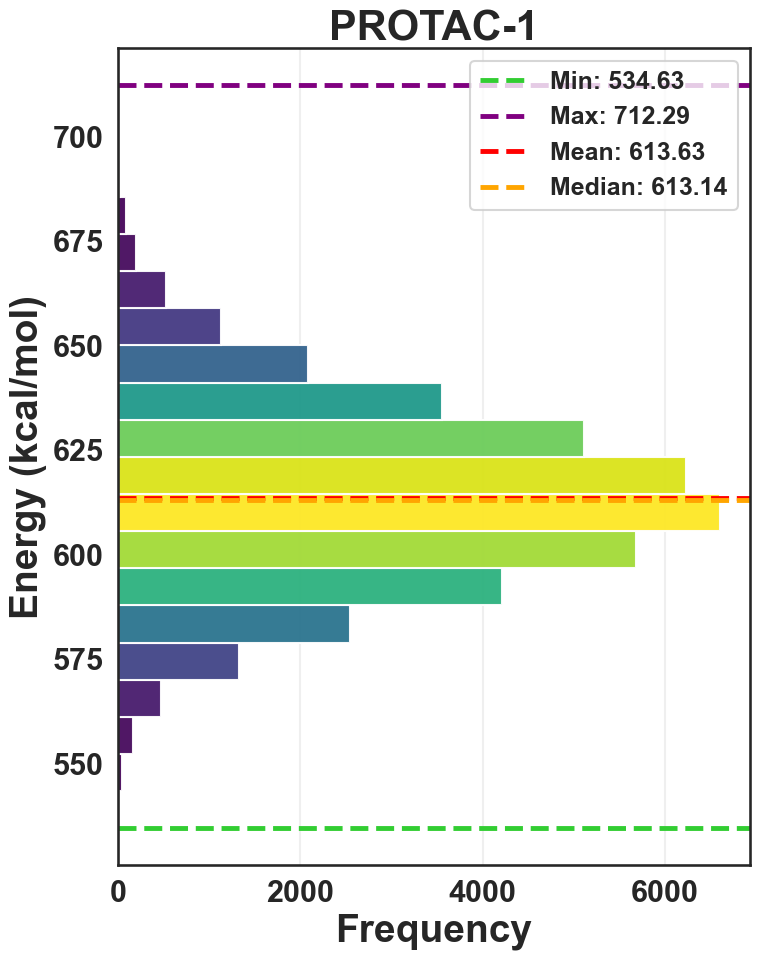

In [ ]:
## Energy histogram

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
 

ELIM_ENERGY = None   # Example: (600, 800)

df_energy = pd.read_csv(f"sasa_rg_energy_{protac_name}_{run_id}_{name_prefix}.csv")
df_energy = df_energy.dropna(subset=["Energy"]).copy()

if ELIM_ENERGY is not None:
    df_energy = df_energy[
        (df_energy["Energy"] >= ELIM_ENERGY[0]) &
        (df_energy["Energy"] <= ELIM_ENERGY[1])
    ].copy()

if df_energy.empty:
    raise ValueError("No energy data left after filtering.")

energies = df_energy["Energy"]

counts, bins = np.histogram(energies, bins=20)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
bin_width = bins[1] - bins[0]

plt.rcParams.update({
    "font.size": 20,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 28,
    "axes.titlesize": 30,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 18,
})

fig, ax = plt.subplots(figsize=(8, 10))

norm = counts / counts.max()
colors = plt.cm.viridis(norm)

ax.barh(
    bin_centers,
    counts,
    height=bin_width,
    color=colors,
    edgecolor="white",
    alpha=0.95
)

min_e = energies.min()
max_e = energies.max()
mean_e = energies.mean()
median_e = energies.median()

ax.axhline(min_e, color="limegreen", linestyle="--", linewidth=3.5,
           label=f"Min: {min_e:.2f}")
ax.axhline(max_e, color="purple", linestyle="--", linewidth=3.5,
           label=f"Max: {max_e:.2f}")
ax.axhline(mean_e, color="red", linestyle="--", linewidth=3.5,
           label=f"Mean: {mean_e:.2f}")
ax.axhline(median_e, color="orange", linestyle="--", linewidth=3.5,
           label=f"Median: {median_e:.2f}")

ax.set_xlabel("Frequency", fontweight="bold")
ax.set_ylabel("Energy (kcal/mol)", fontweight="bold")
ax.set_title(f"{protac_name}", fontweight="bold")

ax.grid(axis="x", alpha=0.3)

ax.tick_params(axis="both", width=2.5, length=7)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

ax.legend(fontsize=18)

plt.tight_layout()

output_png = f"energy_histogram_flipped_{protac_name}_{run_id}_{name_prefix}.png"
plt.savefig(output_png, dpi=300, bbox_inches="tight")

print(f"✅ Saved: {output_png}")

plt.show()
plt.close()

In [ ]:

# --- INPUTS for IHB---
top_file_hb = "ligand_hb.pdb"   # PDB that matches the XTC (same atoms & order)
xtc_file_hb = "ligand_hb.xtc"   # your XTC trajectory

In [ ]:
## Analyzes intramolecular hydrogen bonds (H-bonds) in a molecule
# HB setting_ cutoff and atom definition 

eligible_atoms = [7, 8]  # N and O
cutoff = 3.0  # H-bond cutoff distance

In [61]:
# Hydrogen Bond Analysis and Feature Calculation from ligand_hb.pdb / ligand_hb.xtc

import os
import tempfile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import acos, degrees
from numpy import dot, linalg
from rdkit import Chem
from rdkit.Chem import rdmolops
import matplotlib.ticker as ticker
import mdtraj as md

traj = md.load(xtc_file_hb, top=top_file_hb)
print(f"Found {traj.n_frames} frames in {xtc_file_hb}")

def calculate_angle(v1, v2):
    cos_theta = dot(v1, v2) / (linalg.norm(v1) * linalg.norm(v2))
    cos_theta = min(1.0, max(-1.0, cos_theta))
    return degrees(acos(cos_theta))

def find_backbone_atoms(mol, atom1_idx, atom2_idx):
    path = rdmolops.GetShortestPath(mol, atom1_idx, atom2_idx)
    return len(path) - 1 if path else 0

def find_intramolecular_hbonds(mol, confId=-1, eligibleAtoms=[7, 8], distTol=3.0):
    res = []
    conf = mol.GetConformer(confId)

    for i in range(mol.GetNumAtoms()):
        atom_h = mol.GetAtomWithIdx(i)

        if atom_h.GetAtomicNum() != 1 or atom_h.GetDegree() != 1:
            continue

        donor_atom = atom_h.GetNeighbors()[0]
        if donor_atom.GetAtomicNum() not in eligibleAtoms:
            continue

        donor_pos = conf.GetAtomPosition(donor_atom.GetIdx())
        hydrogen_pos = conf.GetAtomPosition(i)

        for j in range(mol.GetNumAtoms()):
            if j == i:
                continue

            acceptor_atom = mol.GetAtomWithIdx(j)

            if acceptor_atom.GetAtomicNum() not in eligibleAtoms:
                continue

            if mol.GetBondBetweenAtoms(i, j):
                continue

            acceptor_pos = conf.GetAtomPosition(j)
            dist = (hydrogen_pos - acceptor_pos).Length()

            if dist < distTol:
                v1 = hydrogen_pos - donor_pos
                v2 = hydrogen_pos - acceptor_pos
                angle = calculate_angle(v1, v2)
                ring_size = int(find_backbone_atoms(mol, donor_atom.GetIdx(), j) + 2)

                res.append((
                    i + 1,
                    donor_atom.GetIdx() + 1,
                    j + 1,
                    dist,
                    angle,
                    ring_size
                ))

    return res

hb_counts = []
all_lengths = []
all_angles = []
all_ring_sizes = []

for idx in range(traj.n_frames):
    with tempfile.NamedTemporaryFile(suffix=".pdb", delete=False) as tmp:
        temp_pdb = tmp.name

    try:
        traj[idx].save_pdb(temp_pdb)

        mol = Chem.MolFromPDBFile(temp_pdb, removeHs=False, sanitize=True)
        if mol is None:
            hb_counts.append(0)
            continue

        hbonds_data = find_intramolecular_hbonds(
            mol,
            confId=-1,
            distTol=cutoff,
            eligibleAtoms=eligible_atoms
        )

        hb_counts.append(len(hbonds_data))

        if len(hbonds_data) == 0:
            continue

        lengths = [r[3] for r in hbonds_data]
        angles = [r[4] for r in hbonds_data]
        ring_sizes = [r[5] for r in hbonds_data]

        all_lengths.extend(lengths)
        all_angles.extend(angles)
        all_ring_sizes.extend(ring_sizes)

    except Exception as e:
        print(f"Error in frame {idx}: {e}")
        hb_counts.append(0)

    finally:
        if os.path.exists(temp_pdb):
            os.remove(temp_pdb)

df_hb_summary = pd.DataFrame({
    "frame": np.arange(len(hb_counts)),
    "time_ns": np.arange(len(hb_counts)) / 50.0,
    "hb_count": hb_counts
})

print(df_hb_summary.head())

Found 5001 frames in ligand_hb.xtc
   frame  time_ns  hb_count
0      0     0.00        10
1      1     0.02        10
2      2     0.04        11
3      3     0.06        10
4      4     0.08        10


/var/folders/rv/rfqjwyh15mlglm2fl7dngw4r0000gn/T/ipykernel_75455/3618777586.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


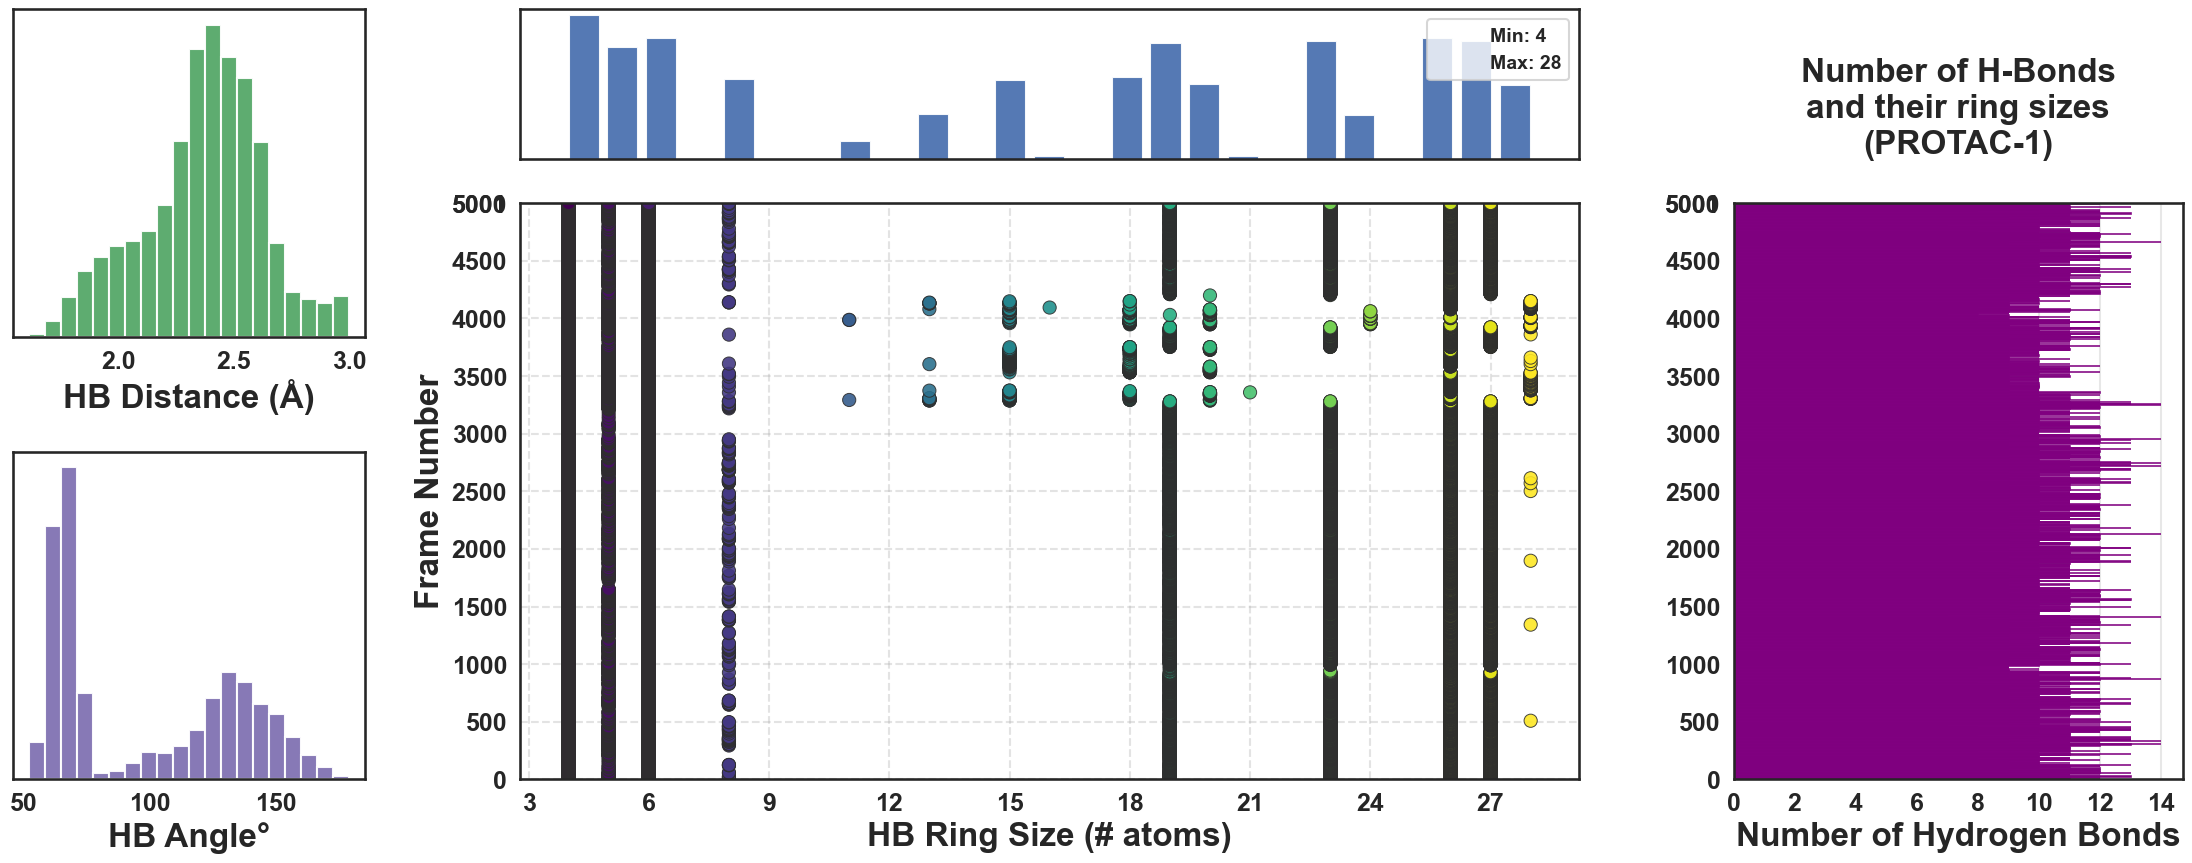

📍 Combined plot saved to: PROTAC-1_1_Chloroform_combined_full_analysis.png


In [ ]:
# summary plot of hydrogen bond analysis

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec

ring_values = [int(r) for r in all_ring_sizes]

conf_indices = []
for frame_idx, count in enumerate(hb_counts):
    conf_indices.extend([frame_idx + 1] * int(count))

n = min(len(ring_values), len(conf_indices))
ring_values = ring_values[:n]
conf_indices = conf_indices[:n]

# style
plt.rcParams.update({
    "font.size": 20,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 24,
    "axes.titlesize": 24,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
})

ring_color = "#4C72B0"
dist_color = "#55A868"
angle_color = "#8172B2"
hb_color = "#6C757D"
edge_color = "#2F2F2F"
grid_color = "#B0B0B0"

fig = plt.figure(figsize=(28, 10))

outer = GridSpec(
    1, 3,
    width_ratios=[1.1, 3.3, 1.4],
    wspace=0.25
)

left_gs = outer[0].subgridspec(
    2, 1,
    height_ratios=[1, 1],
    hspace=0.35
)

middle_gs = outer[1].subgridspec(
    2, 1,
    height_ratios=[1.3, 5],
    hspace=0.12
)

right_gs = outer[2].subgridspec(
    2, 1,
    height_ratios=[1.3, 5],
    hspace=0.12
)

ax_dist_hist = fig.add_subplot(left_gs[0, 0])
ax_angle_hist = fig.add_subplot(left_gs[1, 0])
ax_ring_hist = fig.add_subplot(middle_gs[0, 0])
ax_ring_scatter = fig.add_subplot(middle_gs[1, 0])
ax_hb_count = fig.add_subplot(right_gs[1, 0], sharey=ax_ring_scatter)

# ========== LEFT TOP: HB distance
ax_dist_hist.hist(
    all_lengths,
    bins=20,
    color=dist_color,
    edgecolor="white",
    linewidth=1.5,
    alpha=0.95
)

ax_dist_hist.set_title("")
ax_dist_hist.set_xlabel("HB Distance (Å)")
ax_dist_hist.set_ylabel("")
ax_dist_hist.set_yticks([])
ax_dist_hist.grid(axis="y", color=grid_color, alpha=0.3)

# ========== LEFT BOTTOM: HB angle
ax_angle_hist.hist(
    all_angles,
    bins=20,
    color=angle_color,
    edgecolor="white",
    linewidth=1.5,
    alpha=0.95
)

ax_angle_hist.set_title("")
ax_angle_hist.set_xlabel("HB Angle°")
ax_angle_hist.set_ylabel("")
ax_angle_hist.set_yticks([])
ax_angle_hist.grid(axis="y", color=grid_color, alpha=0.3)

# ========== TOP MIDDLE: Ring size histogram
if ring_values:
    ring_bins = sorted(set(ring_values))
    counts = [ring_values.count(r) for r in ring_bins]

    min_ring = min(ring_values)
    max_ring = max(ring_values)

    ax_ring_hist.bar(
        ring_bins,
        counts,
        color=ring_color,
        edgecolor="white",
        linewidth=1.5,
        alpha=0.95
    )

    ax_ring_hist.plot([], [], color="none", label=f"Min: {min_ring}")
    ax_ring_hist.plot([], [], color="none", label=f"Max: {max_ring}")

    ax_ring_hist.set_yscale("log")
    ax_ring_hist.set_ylim(0.8, max(counts) * 1.5)
    ax_ring_hist.grid(axis="y", color=grid_color, alpha=0.3, which="both")

    ax_ring_hist.set_xlabel("")
    ax_ring_hist.set_ylabel("")
    ax_ring_hist.set_yticks([])
    ax_ring_hist.tick_params(axis="x", labelbottom=False)
    ax_ring_hist.legend()

# ========== BOTTOM MIDDLE: Ring size vs Frame
if ring_values:
    ring_array = np.array(ring_values)
    norm = (ring_array - ring_array.min()) / (
        ring_array.max() - ring_array.min() + 1e-6
    )
    colors = plt.cm.viridis(norm)
else:
    colors = ring_color

ax_ring_scatter.scatter(
    ring_values,
    conf_indices,
    c=colors,
    edgecolor=edge_color,
    linewidth=0.7,
    alpha=0.9,
    s=90
)

ax_ring_scatter.set_xlabel("HB Ring Size (# atoms)")
ax_ring_scatter.set_ylabel("Frame Number")
ax_ring_scatter.grid(True, linestyle="--", color=grid_color, alpha=0.35)

if ring_values:
    ax_ring_scatter.set_xticks(range(min(ring_values), max(ring_values) + 1))
    ax_ring_scatter.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# ========== RIGHT BOTTOM: HB count
ax_hb_count.barh(
    range(1, len(hb_counts) + 1),
    hb_counts,
    color=hb_color,
    edgecolor="purple",
    linewidth=1.2,
    alpha=0.95
)

ax_hb_count.set_xlabel("Number of Hydrogen Bonds")
ax_hb_count.set_title(
    "Number of H-Bonds\nand their ring sizes\n"
    f"({protac_name})\n",
    pad=10
)

ax_hb_count.grid(axis="x", color=grid_color, alpha=0.3)
ax_hb_count.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))


if conf_indices or hb_counts:
    ymax = max(max(conf_indices) if conf_indices else 0, len(hb_counts))

    ax_ring_scatter.set_ylim(0, ymax + 1)
    ax_hb_count.set_ylim(0, ymax + 1)

    step = max(1, ymax // 10)
    yticks = list(range(0, ymax + 1, step))

    if ymax not in yticks:
        yticks.append(ymax)

    ax_ring_scatter.set_yticks(yticks)
    ax_hb_count.set_yticks(yticks)


for ax in [
    ax_dist_hist,
    ax_angle_hist,
    ax_ring_hist,
    ax_ring_scatter,
    ax_hb_count
]:
    ax.tick_params(axis="both", width=2, length=6)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()

combined_plot_path = f"{protac_name}_{run_id}_{name_prefix}_combined_full_analysis.png"

plt.savefig(combined_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"📍 Combined plot saved to: {combined_plot_path}")

In [65]:
# important numbers

import numpy as np
import pandas as pd

# ---- Load SINGLE combined file ----
df = pd.read_csv(f"sasa_rg_energy_psa_{protac_name}_{run_id}_{name_prefix}.csv")

print("FULL SUMMARY STATISTICS:\n")

# ---- SASA ----
print("SASA (Å²):")
print(f"  min   : {df['SASA'].min():.3f}")
print(f"  max   : {df['SASA'].max():.3f}")
print(f"  mean  : {df['SASA'].mean():.3f}")
print(f"  median: {df['SASA'].median():.3f}")

# ---- Rg ----
print("\nRadius of Gyration (Å):")
print(f"  min   : {df['Rg'].min():.3f}")
print(f"  max   : {df['Rg'].max():.3f}")
print(f"  mean  : {df['Rg'].mean():.3f}")
print(f"  median: {df['Rg'].median():.3f}")

# ---- Energy ----
print("\nEnergy (kcal/mol):")
print(f"  min   : {df['Energy'].min():.3f}")
print(f"  max   : {df['Energy'].max():.3f}")
print(f"  mean  : {df['Energy'].mean():.3f}")
print(f"  median: {df['Energy'].median():.3f}")

# ---- PSA ----
print("\nPSA (Å²):")
print(f"  min   : {df['PSA'].min():.3f}")
print(f"  max   : {df['PSA'].max():.3f}")
print(f"  mean  : {df['PSA'].mean():.3f}")
print(f"  median: {df['PSA'].median():.3f}")

# ---- H-bond count ----
print("\nNumber of H-bonds per frame:")
if len(hb_counts) > 0:
    hb_counts_arr = np.array(hb_counts)
    print(f"  min   : {hb_counts_arr.min():.3f}")
    print(f"  max   : {hb_counts_arr.max():.3f}")
    print(f"  mean  : {hb_counts_arr.mean():.3f}")
    print(f"  median: {np.median(hb_counts_arr):.3f}")
else:
    print("  No data available.")

# ---- Ring size ----
print("\nRing size (# atoms):")
if len(all_ring_sizes) > 0:
    ring_sizes_arr = np.array(all_ring_sizes)
    print(f"  min   : {ring_sizes_arr.min():.3f}")
    print(f"  max   : {ring_sizes_arr.max():.3f}")
    print(f"  mean  : {ring_sizes_arr.mean():.3f}")
    print(f"  median: {np.median(ring_sizes_arr):.3f}")
else:
    print("  No data available.")

# ---- HB distance ----
print("\nH-bond distance (Å):")
if len(all_lengths) > 0:
    lengths_arr = np.array(all_lengths)
    print(f"  min   : {lengths_arr.min():.3f}")
    print(f"  max   : {lengths_arr.max():.3f}")
    print(f"  mean  : {lengths_arr.mean():.3f}")
    print(f"  median: {np.median(lengths_arr):.3f}")
else:
    print("  No data available.")

# ---- HB angle ----
print("\nH-bond angle (°):")
if len(all_angles) > 0:
    angles_arr = np.array(all_angles)
    print(f"  min   : {angles_arr.min():.3f}")
    print(f"  max   : {angles_arr.max():.3f}")
    print(f"  mean  : {angles_arr.mean():.3f}")
    print(f"  median: {np.median(angles_arr):.3f}")
else:
    print("  No data available.")

FULL SUMMARY STATISTICS:

SASA (Å²):
  min   : 815.785
  max   : 1159.038
  mean  : 978.440
  median: 980.884

Radius of Gyration (Å):
  min   : 4.554
  max   : 8.219
  mean  : 5.655
  median: 5.657

Energy (kcal/mol):
  min   : 534.630
  max   : 712.290
  mean  : 613.635
  median: 613.144

PSA (Å²):
  min   : 157.409
  max   : 294.534
  mean  : 194.976
  median: 194.194

Number of H-bonds per frame:
  min   : 6.000
  max   : 14.000
  mean  : 9.937
  median: 10.000

Ring size (# atoms):
  min   : 4.000
  max   : 28.000
  mean  : 11.033
  median: 4.000

H-bond distance (Å):
  min   : 1.608
  max   : 3.000
  mean  : 2.368
  median: 2.394

H-bond angle (°):
  min   : 51.944
  max   : 179.354
  mean  : 98.822
  median: 75.766


In [67]:
import numpy as np
import pandas as pd

# ---- Load combined file ----
df = pd.read_csv(f"sasa_rg_energy_psa_{protac_name}_{run_id}_{name_prefix}.csv")

# ---- Arrays ----
hb_counts_arr = np.array(hb_counts, dtype=float)
ring_sizes_arr = np.array(all_ring_sizes, dtype=float)
lengths_arr = np.array(all_lengths, dtype=float)
angles_arr = np.array(all_angles, dtype=float)

# ---- Helper ----
def get_stats(prefix, arr):
    arr = np.array(arr, dtype=float)
    arr = arr[~np.isnan(arr)]

    if len(arr) == 0:
        return {
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_mean": np.nan,
            f"{prefix}_median": np.nan
        }

    return {
        f"{prefix}_min": np.min(arr),
        f"{prefix}_max": np.max(arr),
        f"{prefix}_mean": np.mean(arr),
        f"{prefix}_median": np.median(arr)
    }

# ---- Build ONE ROW wide format ----
summary = {}

summary.update(get_stats("sasa_A2", df["SASA"]))
summary.update(get_stats("rg_A", df["Rg"]))
summary.update(get_stats("energy", df["Energy"]))
summary.update(get_stats("psa_A2", df["PSA"]))
summary.update(get_stats("hb_count", hb_counts_arr))
summary.update(get_stats("ring_size", ring_sizes_arr))
summary.update(get_stats("hb_distance_A", lengths_arr))
summary.update(get_stats("hb_angle_deg", angles_arr))

summary_df = pd.DataFrame([summary]).round(3)

# ---- Save ----
output_csv = f"summary_stats_{protac_name}_{run_id}_{name_prefix}.csv"
summary_df.to_csv(output_csv, index=False)

display(summary_df)

print(f"✅ Summary saved to {output_csv}")

,sasa_A2_min,sasa_A2_max,sasa_A2_mean,sasa_A2_median,rg_A_min,rg_A_max,rg_A_mean,rg_A_median,energy_min,energy_max,...,ring_size_mean,ring_size_median,hb_distance_A_min,hb_distance_A_max,hb_distance_A_mean,hb_distance_A_median,hb_angle_deg_min,hb_angle_deg_max,hb_angle_deg_mean,hb_angle_deg_median
0,815.786,1159.038,978.44,980.884,4.554,8.219,5.655,5.657,534.63,712.29,...,11.033,4.0,1.608,3.0,2.368,2.394,51.944,179.354,98.822,75.766


✅ Summary saved to summary_stats_PROTAC-1_1_Chloroform.csv
